This notebook looks at the correlation of the fitted data with the empirical FC

In [28]:
# Imports

from hbnm.bnm import Bnm
from hbnm.io import Data
import os
import numpy as np
from hbnm.model.utils import subdiag, fisher_z, linearize_map
from scipy.stats import pearsonr
import matplotlib.pyplot as plt


In [24]:
# Set up data loader
input_dir = "/home/frank/HBNM/data/"
output_dir = "/home/frank/HBNM/outputs/"
data = Data(input_dir, output_dir)  

# Load HCP SC and Empirical FC Matrices
sc, _, fc_obj = data.load_demirtas_neuron_2019_data()
empirical_fc = subdiag(fc_obj)

In [3]:
# Load the fitted parameters for all the maps

# Standardized simulation names that match the rest of the code
simulations = ['dopamine', 'gaba', 'norepinephrine', 'nmda', 'myelin']

# Dictionary to store theta values for each simulation
theta_values = {}

# Latest iterations for each simulation (mapping standardized names to file paths)
latest_iterations = {
    'dopamine': 28,
    'gaba': 33, 
    'norepinephrine': 30,
    'nmda': 41,
    'myelin': 35
}

# Mapping from standardized names to file directory names
file_mapping = {
    'dopamine': 'Dopamine_AVG',
    'gaba': 'GABAa_AVG',
    'norepinephrine': 'Norepinephrine_AVG',
    'nmda': 'NMDA_AVG',
    'myelin': 'Heterogenous'
}

# Load theta values for each simulation
for sim in simulations:
    iteration = latest_iterations[sim]
    file_dir = file_mapping[sim]
    fin = data.load(f'{file_dir}/iteration_{iteration}.hdf5', from_output=True)
    theta_values[sim] = fin['theta'][:]
    fin.close()
    print(f"Loaded theta values for {sim} from iteration {iteration}")

Loaded theta values for dopamine from iteration 28
Loaded theta values for gaba from iteration 33
Loaded theta values for norepinephrine from iteration 30
Loaded theta values for nmda from iteration 41
Loaded theta values for myelin from iteration 35


In [7]:
for sim in simulations:
    print(f"{sim} shape: {theta_values[sim].shape}")

dopamine shape: (5, 300)
gaba shape: (5, 300)
norepinephrine shape: (5, 300)
nmda shape: (5, 300)
myelin shape: (5, 300)


In [14]:
# Load and linearize all receptor maps

# Dictionary to store all linearized empirical maps
empirical_maps = {}
# Directory containing the receptor vectors
receptor_dir = "/home/frank/HBNM/data/receptor_vectors"
# Get all .npy files in the receptor_vectors directory
receptor_files = [f for f in os.listdir(receptor_dir) if f.endswith('.npy')]
# Load and linearize each empirical map
for file in receptor_files:
    # Extract map name (remove 'y_vector_' prefix and '.npy' suffix)
    map_name = file.replace('y_vector_', '').replace('.npy', '')
    # Load the map
    map_data = np.load(os.path.join(receptor_dir, file))
    # Linearize the map
    linearized_map = linearize_map(map_data)
    # Ensure it's in (1, N) format
    if linearized_map.ndim == 1:
        linearized_map = linearized_map.reshape(1, -1)
    elif linearized_map.shape[0] != 1:
        linearized_map = linearized_map.reshape(1, -1)
    # Store in dictionary
    empirical_maps[map_name] = linearized_map
    print(f"Loaded and linearized {map_name} map: shape {linearized_map.shape}")

print(f"Available empirical maps: {list(empirical_maps.keys())}")

Loaded and linearized myelin map: shape (1, 180)
Loaded and linearized nmda map: shape (1, 180)
Loaded and linearized gaba map: shape (1, 180)
Loaded and linearized norepinephrine map: shape (1, 180)
Loaded and linearized dopamine map: shape (1, 180)
Available empirical maps: ['myelin', 'nmda', 'gaba', 'norepinephrine', 'dopamine']


In [15]:
empirical_maps

{'myelin': array([[ 9.54818594e-01,  8.96991699e-01,  8.96873969e-01,
          8.96049237e-01,  8.39703904e-01,  7.70226768e-01,
          7.17796094e-01,  9.90905961e-01,  9.50437376e-01,
          3.87478895e-01,  1.79292068e-01,  4.48695494e-02,
          8.95337997e-01,  9.99143731e-01,  5.15787729e-01,
          8.12401429e-01,  4.80177471e-01,  3.07301373e-01,
          7.47295094e-01,  5.99922952e-01,  5.18634181e-01,
          4.51286952e-01,  8.70888786e-01,  9.99720093e-01,
         -2.96265780e-01, -6.23942052e-01, -1.17472036e-01,
         -2.68215496e-02, -2.63099926e-01,  1.26310401e-01,
          5.04085993e-01,  5.27763290e-02,  5.37731851e-01,
          5.16525442e-01,  1.68557470e-01,  7.95030401e-01,
         -1.15739498e-01, -4.15790878e-01, -2.15986666e-01,
          6.69884260e-01, -2.01338724e-01, -2.63395813e-01,
         -1.90878079e-01, -5.25864415e-01, -4.70703980e-01,
         -3.59815278e-02,  1.33557394e-01,  6.44301396e-01,
          1.89249756e-01,  2.8

**Myelin**

Processing myelin...
Completed myelin: 300 correlations calculated


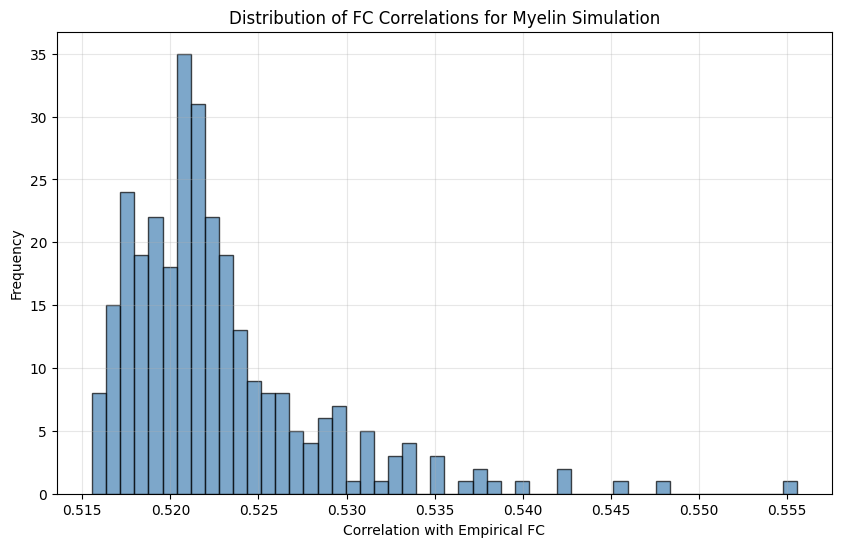


Summary Statistics for myelin:
Mean = 0.5227
Std = 0.0056
Min = 0.5156
Max = 0.5555
Median = 0.5215


In [30]:
# Select which simulation to analyze
selected_simulation = 'myelin'  # Change this to: 'dopamine', 'gaba', 'norepinephrine', 'nmda', or 'myelin'

print(f"Processing {selected_simulation}...")

# Initialize list to store correlations for the selected simulation
correlations = []

# Loop through all theta value columns (300 parameter sets) for the selected simulation
for i in range(theta_values[selected_simulation].shape[1]):
    # Set up model with selected simulation's empirical map
    model = Bnm(sc, maps=empirical_maps[selected_simulation])
    
    # Set parameters using current theta values
    model.set('w_EI', (theta_values[selected_simulation][0,i], theta_values[selected_simulation][1,i]))
    model.set('w_EE', (theta_values[selected_simulation][2,i], theta_values[selected_simulation][3,i]))
    model.set('G', theta_values[selected_simulation][4,i])
    
    # Run model
    model.moments_method()
    model_FC = model.get('corr_bold')
    model_fc = subdiag(model_FC)
    
    # Calculate correlation with empirical FC
    corr, _ = pearsonr(empirical_fc, model_fc)
    correlations.append(corr)

print(f"Completed {selected_simulation}: {len(correlations)} correlations calculated")

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(correlations, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
plt.xlabel('Correlation with Empirical FC')
plt.ylabel('Frequency')
plt.title(f'Distribution of FC Correlations for {selected_simulation.capitalize()} Simulation')
plt.grid(True, alpha=0.3)
plt.show()

# Print summary statistics
print(f"\nSummary Statistics for {selected_simulation}:")
print(f"Mean = {np.mean(correlations):.4f}")
print(f"Std = {np.std(correlations):.4f}")
print(f"Min = {np.min(correlations):.4f}")
print(f"Max = {np.max(correlations):.4f}")
print(f"Median = {np.median(correlations):.4f}")


**NMDA** 

DO NOT INVERT THE MAP

Processing nmda...
Processed 50/300 parameter sets...
Processed 100/300 parameter sets...
Processed 150/300 parameter sets...
Processed 200/300 parameter sets...
Processed 250/300 parameter sets...
Processed 300/300 parameter sets...

Completed nmda:
Total parameter sets: 300
Successful correlations: 300
Rejected parameter sets: 0
Success rate: 100.0%


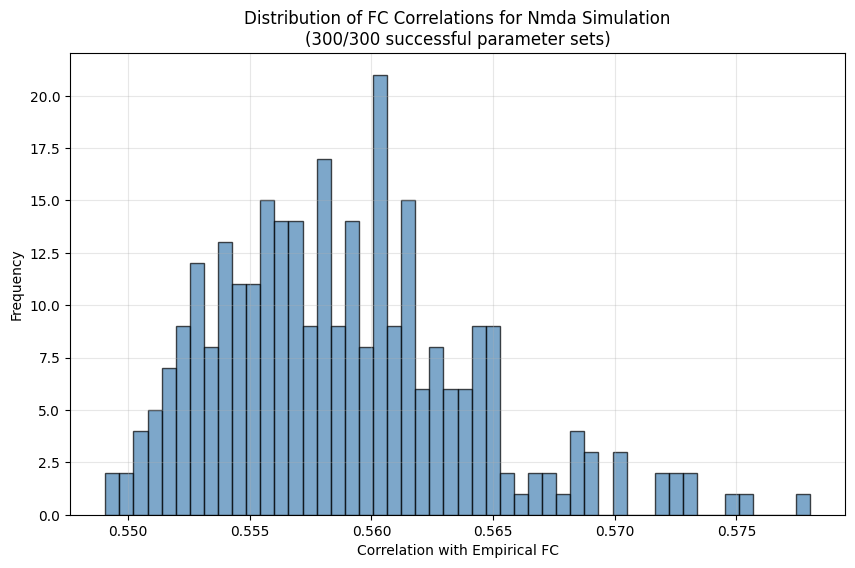


Summary Statistics for nmda (successful parameter sets only):
Mean = 0.5588
Std = 0.0052
Min = 0.5491
Max = 0.5780
Median = 0.5581


In [34]:
# Select which simulation to analyze
selected_simulation = 'nmda'  # Change this to: 'dopamine', 'gaba', 'norepinephrine', 'nmda', or 'myelin'

print(f"Processing {selected_simulation}...")

# Initialize list to store correlations for the selected simulation
correlations = []
rejected_count = 0
total_count = theta_values[selected_simulation].shape[1]

# Loop through all theta value columns (300 parameter sets) for the selected simulation
for i in range(total_count):
    try:
        # Set up model with selected simulation's empirical map
        model = Bnm(sc, maps=empirical_maps[selected_simulation], map_invert_flags=[False])
        
        # Set parameters using current theta values
        model.set('w_EI', (theta_values[selected_simulation][0,i], theta_values[selected_simulation][1,i]))
        model.set('w_EE', (theta_values[selected_simulation][2,i], theta_values[selected_simulation][3,i]))
        model.set('G', theta_values[selected_simulation][4,i])
        
        # Run model
        model.moments_method()
        model_FC = model.get('corr_bold')
        
        # Check if model_FC is None or invalid
        if model_FC is None:
            print(f"Warning: Parameter set {i} returned None for FC matrix - skipping")
            rejected_count += 1
            continue
            
        # Try to extract subdiagonal
        model_fc = subdiag(model_FC)
        
        # Check if we got a valid result
        if model_fc is None or len(model_fc) == 0:
            print(f"Warning: Parameter set {i} returned empty subdiagonal - skipping")
            rejected_count += 1
            continue
        
        # Calculate correlation with empirical FC
        corr, _ = pearsonr(empirical_fc, model_fc)
        
        # Check if correlation is valid (not NaN)
        if np.isnan(corr):
            print(f"Warning: Parameter set {i} returned NaN correlation - skipping")
            rejected_count += 1
            continue
            
        correlations.append(corr)
        
        # Print progress every 50 iterations
        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{total_count} parameter sets...")
            
    except Exception as e:
        print(f"Error with parameter set {i}: {str(e)} - skipping")
        rejected_count += 1
        continue

successful_count = len(correlations)
print(f"\nCompleted {selected_simulation}:")
print(f"Total parameter sets: {total_count}")
print(f"Successful correlations: {successful_count}")
print(f"Rejected parameter sets: {rejected_count}")
print(f"Success rate: {successful_count/total_count*100:.1f}%")

# Only create histogram if we have valid correlations
if successful_count > 0:
    # Create histogram
    plt.figure(figsize=(10, 6))
    plt.hist(correlations, bins=min(50, successful_count//2), alpha=0.7, edgecolor='black', color='steelblue')
    plt.xlabel('Correlation with Empirical FC')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of FC Correlations for {selected_simulation.capitalize()} Simulation\n'
              f'({successful_count}/{total_count} successful parameter sets)')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print summary statistics
    print(f"\nSummary Statistics for {selected_simulation} (successful parameter sets only):")
    print(f"Mean = {np.mean(correlations):.4f}")
    print(f"Std = {np.std(correlations):.4f}")
    print(f"Min = {np.min(correlations):.4f}")
    print(f"Max = {np.max(correlations):.4f}")
    print(f"Median = {np.median(correlations):.4f}")
else:
    print("No valid correlations were calculated - cannot create histogram or statistics")

# Show rejection details
if rejected_count > 0:
    print(f"\n{rejected_count} parameter sets were rejected due to:")
    print("- Model returning None for FC matrix")
    print("- Empty subdiagonal extraction")
    print("- NaN correlation values")
    print("- Other numerical errors")

**Norepinephrine**

DO NOT INVERT THE MAP

Processing norepinephrine...
Processed 50/300 parameter sets...
Processed 100/300 parameter sets...
Processed 150/300 parameter sets...
Processed 200/300 parameter sets...
Processed 250/300 parameter sets...
Processed 300/300 parameter sets...

Completed norepinephrine:
Total parameter sets: 300
Successful correlations: 300
Rejected parameter sets: 0
Success rate: 100.0%


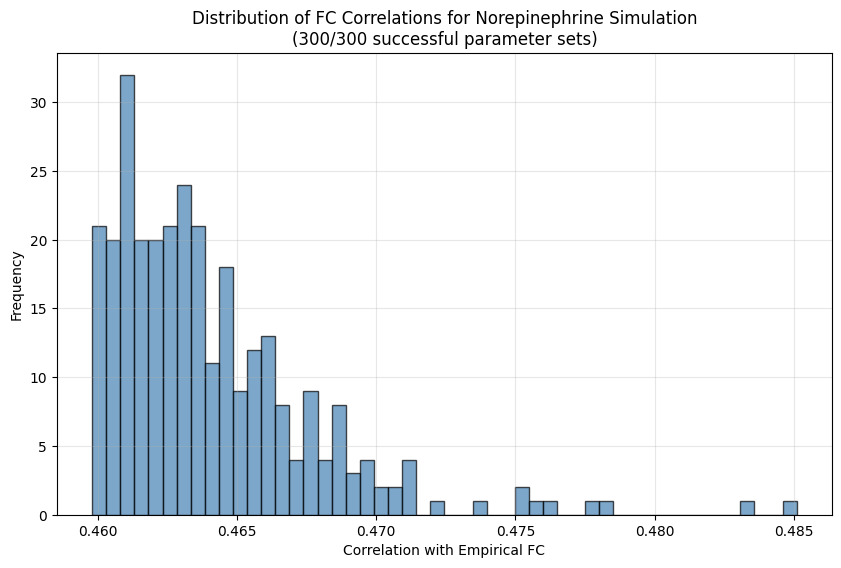


Summary Statistics for norepinephrine (successful parameter sets only):
Mean = 0.4641
Std = 0.0037
Min = 0.4598
Max = 0.4851
Median = 0.4632


In [35]:
# Select which simulation to analyze
selected_simulation = 'norepinephrine'  # Change this to: 'dopamine', 'gaba', 'norepinephrine', 'nmda', or 'myelin'

print(f"Processing {selected_simulation}...")

# Initialize list to store correlations for the selected simulation
correlations = []
rejected_count = 0
total_count = theta_values[selected_simulation].shape[1]

# Loop through all theta value columns (300 parameter sets) for the selected simulation
for i in range(total_count):
    try:
        # Set up model with selected simulation's empirical map
        model = Bnm(sc, maps=empirical_maps[selected_simulation], map_invert_flags=[False])
        
        # Set parameters using current theta values
        model.set('w_EI', (theta_values[selected_simulation][0,i], theta_values[selected_simulation][1,i]))
        model.set('w_EE', (theta_values[selected_simulation][2,i], theta_values[selected_simulation][3,i]))
        model.set('G', theta_values[selected_simulation][4,i])
        
        # Run model
        model.moments_method()
        model_FC = model.get('corr_bold')
        
        # Check if model_FC is None or invalid
        if model_FC is None:
            print(f"Warning: Parameter set {i} returned None for FC matrix - skipping")
            rejected_count += 1
            continue
            
        # Try to extract subdiagonal
        model_fc = subdiag(model_FC)
        
        # Check if we got a valid result
        if model_fc is None or len(model_fc) == 0:
            print(f"Warning: Parameter set {i} returned empty subdiagonal - skipping")
            rejected_count += 1
            continue
        
        # Calculate correlation with empirical FC
        corr, _ = pearsonr(empirical_fc, model_fc)
        
        # Check if correlation is valid (not NaN)
        if np.isnan(corr):
            print(f"Warning: Parameter set {i} returned NaN correlation - skipping")
            rejected_count += 1
            continue
            
        correlations.append(corr)
        
        # Print progress every 50 iterations
        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{total_count} parameter sets...")
            
    except Exception as e:
        print(f"Error with parameter set {i}: {str(e)} - skipping")
        rejected_count += 1
        continue

successful_count = len(correlations)
print(f"\nCompleted {selected_simulation}:")
print(f"Total parameter sets: {total_count}")
print(f"Successful correlations: {successful_count}")
print(f"Rejected parameter sets: {rejected_count}")
print(f"Success rate: {successful_count/total_count*100:.1f}%")

# Only create histogram if we have valid correlations
if successful_count > 0:
    # Create histogram
    plt.figure(figsize=(10, 6))
    plt.hist(correlations, bins=min(50, successful_count//2), alpha=0.7, edgecolor='black', color='steelblue')
    plt.xlabel('Correlation with Empirical FC')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of FC Correlations for {selected_simulation.capitalize()} Simulation\n'
              f'({successful_count}/{total_count} successful parameter sets)')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print summary statistics
    print(f"\nSummary Statistics for {selected_simulation} (successful parameter sets only):")
    print(f"Mean = {np.mean(correlations):.4f}")
    print(f"Std = {np.std(correlations):.4f}")
    print(f"Min = {np.min(correlations):.4f}")
    print(f"Max = {np.max(correlations):.4f}")
    print(f"Median = {np.median(correlations):.4f}")
else:
    print("No valid correlations were calculated - cannot create histogram or statistics")

# Show rejection details
if rejected_count > 0:
    print(f"\n{rejected_count} parameter sets were rejected due to:")
    print("- Model returning None for FC matrix")
    print("- Empty subdiagonal extraction")
    print("- NaN correlation values")
    print("- Other numerical errors")

**GABA**

Processing gaba...
Processed 50/300 parameter sets...
Processed 100/300 parameter sets...
Processed 150/300 parameter sets...
Processed 200/300 parameter sets...
Processed 250/300 parameter sets...
Processed 300/300 parameter sets...

Completed gaba:
Total parameter sets: 300
Successful correlations: 300
Rejected parameter sets: 0
Success rate: 100.0%


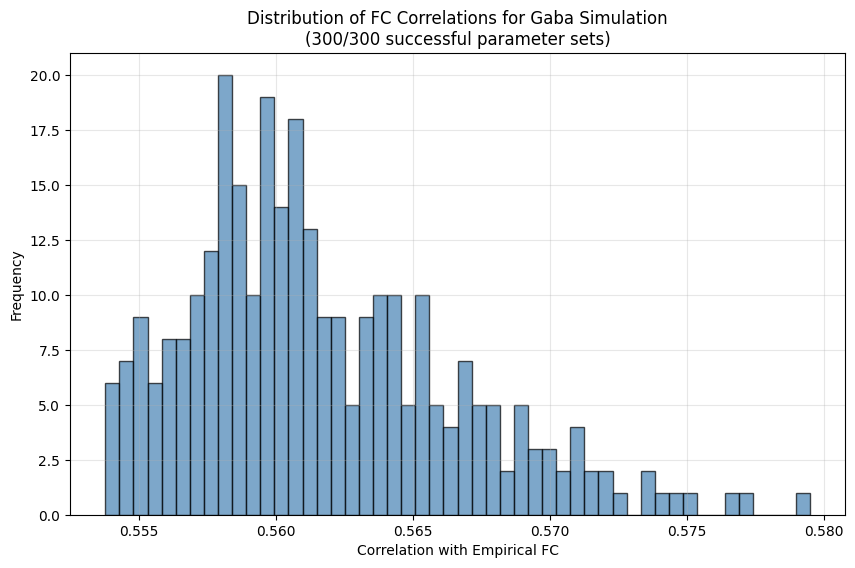


Summary Statistics for gaba (successful parameter sets only):
Mean = 0.5616
Std = 0.0049
Min = 0.5538
Max = 0.5795
Median = 0.5607


In [36]:
# Select which simulation to analyze
selected_simulation = 'gaba'  # Change this to: 'dopamine', 'gaba', 'norepinephrine', 'nmda', or 'myelin'

print(f"Processing {selected_simulation}...")

# Initialize list to store correlations for the selected simulation
correlations = []
rejected_count = 0
total_count = theta_values[selected_simulation].shape[1]

# Loop through all theta value columns (300 parameter sets) for the selected simulation
for i in range(total_count):
    try:
        # Set up model with selected simulation's empirical map
        model = Bnm(sc, maps=empirical_maps[selected_simulation], map_invert_flags=[True])
        
        # Set parameters using current theta values
        model.set('w_EI', (theta_values[selected_simulation][0,i], theta_values[selected_simulation][1,i]))
        model.set('w_EE', (theta_values[selected_simulation][2,i], theta_values[selected_simulation][3,i]))
        model.set('G', theta_values[selected_simulation][4,i])
        
        # Run model
        model.moments_method()
        model_FC = model.get('corr_bold')
        
        # Check if model_FC is None or invalid
        if model_FC is None:
            print(f"Warning: Parameter set {i} returned None for FC matrix - skipping")
            rejected_count += 1
            continue
            
        # Try to extract subdiagonal
        model_fc = subdiag(model_FC)
        
        # Check if we got a valid result
        if model_fc is None or len(model_fc) == 0:
            print(f"Warning: Parameter set {i} returned empty subdiagonal - skipping")
            rejected_count += 1
            continue
        
        # Calculate correlation with empirical FC
        corr, _ = pearsonr(empirical_fc, model_fc)
        
        # Check if correlation is valid (not NaN)
        if np.isnan(corr):
            print(f"Warning: Parameter set {i} returned NaN correlation - skipping")
            rejected_count += 1
            continue
            
        correlations.append(corr)
        
        # Print progress every 50 iterations
        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{total_count} parameter sets...")
            
    except Exception as e:
        print(f"Error with parameter set {i}: {str(e)} - skipping")
        rejected_count += 1
        continue

successful_count = len(correlations)
print(f"\nCompleted {selected_simulation}:")
print(f"Total parameter sets: {total_count}")
print(f"Successful correlations: {successful_count}")
print(f"Rejected parameter sets: {rejected_count}")
print(f"Success rate: {successful_count/total_count*100:.1f}%")

# Only create histogram if we have valid correlations
if successful_count > 0:
    # Create histogram
    plt.figure(figsize=(10, 6))
    plt.hist(correlations, bins=min(50, successful_count//2), alpha=0.7, edgecolor='black', color='steelblue')
    plt.xlabel('Correlation with Empirical FC')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of FC Correlations for {selected_simulation.capitalize()} Simulation\n'
              f'({successful_count}/{total_count} successful parameter sets)')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print summary statistics
    print(f"\nSummary Statistics for {selected_simulation} (successful parameter sets only):")
    print(f"Mean = {np.mean(correlations):.4f}")
    print(f"Std = {np.std(correlations):.4f}")
    print(f"Min = {np.min(correlations):.4f}")
    print(f"Max = {np.max(correlations):.4f}")
    print(f"Median = {np.median(correlations):.4f}")
else:
    print("No valid correlations were calculated - cannot create histogram or statistics")

# Show rejection details
if rejected_count > 0:
    print(f"\n{rejected_count} parameter sets were rejected due to:")
    print("- Model returning None for FC matrix")
    print("- Empty subdiagonal extraction")
    print("- NaN correlation values")
    print("- Other numerical errors")

**Dopamine**

DO NOT INVERT

Processing dopamine...
Processed 50/300 parameter sets...
Processed 100/300 parameter sets...
Processed 150/300 parameter sets...
Processed 200/300 parameter sets...
Processed 250/300 parameter sets...
Processed 300/300 parameter sets...

Completed dopamine:
Total parameter sets: 300
Successful correlations: 300
Rejected parameter sets: 0
Success rate: 100.0%


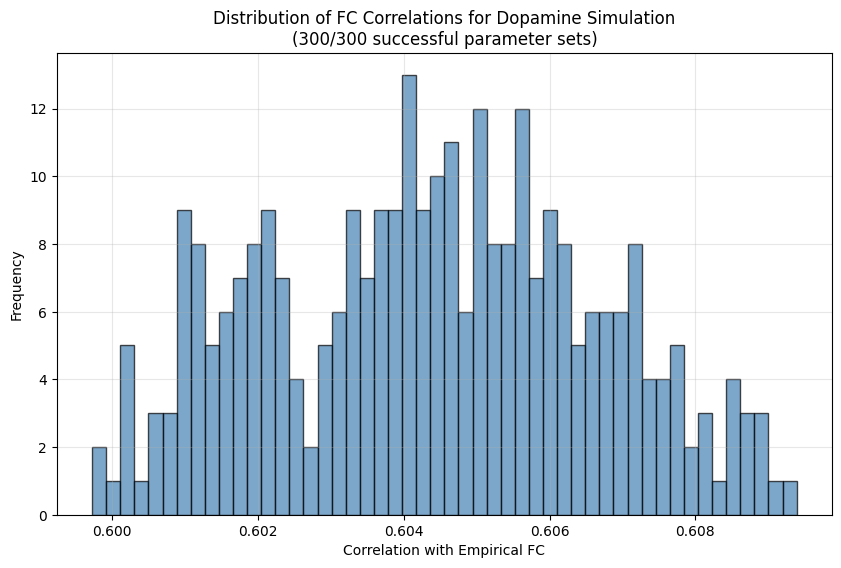


Summary Statistics for dopamine (successful parameter sets only):
Mean = 0.6044
Std = 0.0022
Min = 0.5997
Max = 0.6094
Median = 0.6044


In [37]:
# Select which simulation to analyze
selected_simulation = 'dopamine'  # Change this to: 'dopamine', 'gaba', 'norepinephrine', 'nmda', or 'myelin'

print(f"Processing {selected_simulation}...")

# Initialize list to store correlations for the selected simulation
correlations = []
rejected_count = 0
total_count = theta_values[selected_simulation].shape[1]

# Loop through all theta value columns (300 parameter sets) for the selected simulation
for i in range(total_count):
    try:
        # Set up model with selected simulation's empirical map
        model = Bnm(sc, maps=empirical_maps[selected_simulation], map_invert_flags=[False])
        
        # Set parameters using current theta values
        model.set('w_EI', (theta_values[selected_simulation][0,i], theta_values[selected_simulation][1,i]))
        model.set('w_EE', (theta_values[selected_simulation][2,i], theta_values[selected_simulation][3,i]))
        model.set('G', theta_values[selected_simulation][4,i])
        
        # Run model
        model.moments_method()
        model_FC = model.get('corr_bold')
        
        # Check if model_FC is None or invalid
        if model_FC is None:
            print(f"Warning: Parameter set {i} returned None for FC matrix - skipping")
            rejected_count += 1
            continue
            
        # Try to extract subdiagonal
        model_fc = subdiag(model_FC)
        
        # Check if we got a valid result
        if model_fc is None or len(model_fc) == 0:
            print(f"Warning: Parameter set {i} returned empty subdiagonal - skipping")
            rejected_count += 1
            continue
        
        # Calculate correlation with empirical FC
        corr, _ = pearsonr(empirical_fc, model_fc)
        
        # Check if correlation is valid (not NaN)
        if np.isnan(corr):
            print(f"Warning: Parameter set {i} returned NaN correlation - skipping")
            rejected_count += 1
            continue
            
        correlations.append(corr)
        
        # Print progress every 50 iterations
        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{total_count} parameter sets...")
            
    except Exception as e:
        print(f"Error with parameter set {i}: {str(e)} - skipping")
        rejected_count += 1
        continue

successful_count = len(correlations)
print(f"\nCompleted {selected_simulation}:")
print(f"Total parameter sets: {total_count}")
print(f"Successful correlations: {successful_count}")
print(f"Rejected parameter sets: {rejected_count}")
print(f"Success rate: {successful_count/total_count*100:.1f}%")

# Only create histogram if we have valid correlations
if successful_count > 0:
    # Create histogram
    plt.figure(figsize=(10, 6))
    plt.hist(correlations, bins=min(50, successful_count//2), alpha=0.7, edgecolor='black', color='steelblue')
    plt.xlabel('Correlation with Empirical FC')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of FC Correlations for {selected_simulation.capitalize()} Simulation\n'
              f'({successful_count}/{total_count} successful parameter sets)')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print summary statistics
    print(f"\nSummary Statistics for {selected_simulation} (successful parameter sets only):")
    print(f"Mean = {np.mean(correlations):.4f}")
    print(f"Std = {np.std(correlations):.4f}")
    print(f"Min = {np.min(correlations):.4f}")
    print(f"Max = {np.max(correlations):.4f}")
    print(f"Median = {np.median(correlations):.4f}")
else:
    print("No valid correlations were calculated - cannot create histogram or statistics")

# Show rejection details
if rejected_count > 0:
    print(f"\n{rejected_count} parameter sets were rejected due to:")
    print("- Model returning None for FC matrix")
    print("- Empty subdiagonal extraction")
    print("- NaN correlation values")
    print("- Other numerical errors")